In [2]:
pip install matplotlib

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ----- ---------------------------------- 10.2/80.3 kB ? eta -:--:--
     --------------------------------- ---- 71.7/80.3 kB 975.2 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 897.7 kB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     -------------------------- ------------ 81.9/121.0 kB 2.3 MB/s eta 0:00:01
     -------------------------------------- 121.0/121.0 kB 1.8 MB/s eta 0:00:00
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
    -----------------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# LIF Runner (Phase 1)

Run a simple simulation using the LIF neuron class and plot membrane potential and input current.

Simulated 5000 steps (dt=0.0001s). Spikes: 121
Spike times (s): [0.0532 0.0565 0.0598 0.0631 0.0664 0.0697 0.073  0.0763 0.0796 0.0829
 0.0862 0.0895 0.0928 0.0961 0.0994 0.1027 0.106  0.1093 0.1126 0.1159
 0.1192 0.1225 0.1258 0.1291 0.1324 0.1357 0.139  0.1423 0.1456 0.1489
 0.1522 0.1555 0.1588 0.1621 0.1654 0.1687 0.172  0.1753 0.1786 0.1819
 0.1852 0.1885 0.1918 0.1951 0.1984 0.2017 0.205  0.2083 0.2116 0.2149
 0.2182 0.2215 0.2248 0.2281 0.2314 0.2347 0.238  0.2413 0.2446 0.2479
 0.2512 0.2545 0.2578 0.2611 0.2644 0.2677 0.271  0.2743 0.2776 0.2809
 0.2842 0.2875 0.2908 0.2941 0.2974 0.3007 0.304  0.3073 0.3106 0.3139
 0.3172 0.3205 0.3238 0.3271 0.3304 0.3337 0.337  0.3403 0.3436 0.3469
 0.3502 0.3535 0.3568 0.3601 0.3634 0.3667 0.37   0.3733 0.3766 0.3799
 0.3832 0.3865 0.3898 0.3931 0.3964 0.3997 0.403  0.4063 0.4096 0.4129
 0.4162 0.4195 0.4228 0.4261 0.4294 0.4327 0.436  0.4393 0.4426 0.4459
 0.4492]


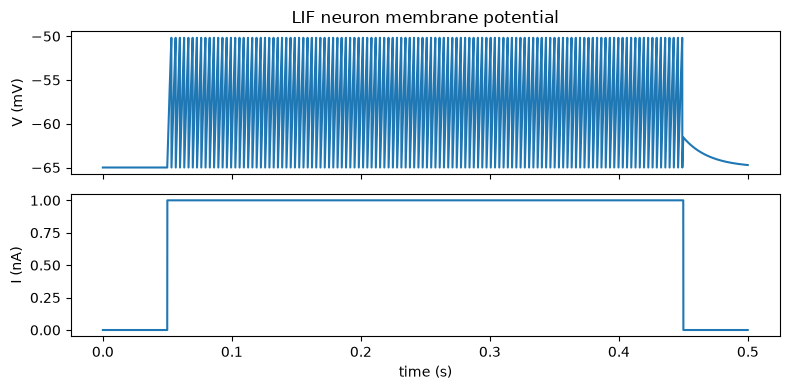

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# LIF class (self-contained copy so this notebook runs standalone)
class LIFNeuron:
    def __init__(self, tau_m=20e-3, R=100e6, v_rest=-65e-3, v_reset=-65e-3, v_th=-50e-3, dt=1e-4):
        self.tau_m = float(tau_m)
        self.R = float(R)
        self.v_rest = float(v_rest)
        self.v_reset = float(v_reset)
        self.v_th = float(v_th)
        self.dt = float(dt)
        self.v = self.v_rest

    def step(self, I_ext):
        dv = (-(self.v - self.v_rest) + self.R * I_ext) * (self.dt / self.tau_m)
        self.v += dv
        if self.v >= self.v_th:
            self.v = self.v_reset
            return 1
        return 0

    def simulate(self, I, dt=None):
        if dt is None:
            dt = self.dt
        I = np.asarray(I, dtype=float)
        n = I.shape[0]
        spikes = np.zeros(n, dtype=int)
        V = np.zeros(n, dtype=float)
        for i in range(n):
            spikes[i] = self.step(I[i])
            V[i] = self.v
        return spikes, V

# Simulation parameters
T = 0.5  # seconds
dt = 1e-4
t = np.arange(0, T, dt)
I = np.zeros_like(t)
I[int(0.05 / dt): int(0.45 / dt)] = 1e-9  # 1 nA pulse

neuron = LIFNeuron(dt=dt)
spikes, V = neuron.simulate(I, dt=dt)
spike_times = t[spikes.astype(bool)]
print(f"Simulated {len(t)} steps (dt={dt}s). Spikes: {len(spike_times)}")
if len(spike_times) > 0:
    print("Spike times (s):", np.round(spike_times, 4))

# Plot
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 4))
ax[0].plot(t, V * 1e3)
ax[0].set_ylabel("V (mV)")
ax[0].set_title("LIF neuron membrane potential")
ax[1].plot(t, I * 1e9)
ax[1].set_ylabel("I (nA)")
ax[1].set_xlabel("time (s)")
plt.tight_layout()
plt.show()